# IMPORTS

In [1]:
%load_ext autoreload

import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax.numpy as jnp

import tol_colors as tc
import matplotlib.pyplot as plt
import plotting_tools.basic_plotting_tools as pts
colors = pts.set_plot_style(default_cmap=tc.sunset)
%matplotlib widget

In [2]:
import differential_geometry.manifolds as manifolds
import differential_geometry.aux_manifolds as aux_manifolds
import plotting_tools.plot_manifolds as plot_manifolds

from scipy.spatial import Delaunay
import differential_geometry.charts as charts
import differential_geometry.aux_charts as aux_charts
import plotting_tools.plot_charts as plot_charts

import differential_geometry.functions as functions
import plotting_tools.plot_functions as plot_functions

import differential_geometry.curves as curves
import differential_geometry.aux_curves as aux_curves
import plotting_tools.plot_curves as plot_curves

import differential_geometry.covectors as covectors
import plotting_tools.plot_covectors as plot_covectors

# 2D-mfd embedded in 3D

In [3]:
manifold = manifolds.Manifold(
    name=r"$\mathcal{M}$", dim=2, ambient_dim=3,
    embedding_func=aux_manifolds.factory_surface_embedding_gaussian_eggs(amplitude=1.0, center=(0.0, 0.0), sigma=(jnp.pi, jnp.pi)),
)

# === Define Charts as intervals in param space ===
center_V = jnp.array([0.7, 0.3])
axes_V = (1.4, 0.9)
x_center_polar, y_center_polar = -1., -1.

# center_V = jnp.array([0.0, 0.0])
# axes_V = (jnp.pi / 3, jnp.pi / 3)
# x_center_polar, y_center_polar = 0.0, 0.0

polar_center = (x_center_polar, y_center_polar)
lambdas = jnp.linspace(0, 2 * jnp.pi, 600)
boundary_V = aux_charts.boundary_ellipse_in_param_space(lambdas, center=center_V, axes=axes_V)
chart_V = charts.Chart(
    name="V", manifold=manifold, boundary=jnp.array(boundary_V),
    chart_map=lambda params: aux_charts.polar_chart_map(params, center=polar_center),
    inverse_chart_map=lambda chart_coords: aux_charts.inverse_polar_chart_map(chart_coords, center=polar_center),
    region_sampler=aux_charts.polar_region_sampler_from_boundary(jnp.array(boundary_V), center=jnp.array(polar_center))
)


center_U = jnp.array([0.1, -0.7])
axes_U = (0.9, 1.5)
boundary_U = aux_charts.boundary_ellipse_in_param_space(lambdas, center=center_U, axes=axes_U)

# lambdas = jnp.linspace(0, 4, 500, endpoint=False)
# boundary_U = charts.boundary_rectangle_in_param_space(
#     lambdas, xlim=(-jnp.pi / 3, jnp.pi / 3), ylim=(-jnp.pi / 3, jnp.pi / 3)
# )

chart_U = charts.Chart(
    name="U", manifold=manifold, boundary=jnp.array(boundary_U),
    chart_map=aux_charts.cartesian_chart_map,
    inverse_chart_map=aux_charts.inverse_cartesian_chart_map,
    region_sampler=aux_charts.polar_region_sampler_from_boundary(
        jnp.array(boundary_U), center=jnp.array(polar_center)
    )
)


boundary_U_cap_V = aux_charts.compute_chart_intersection(boundary_U, boundary_V)

chart_U_cap_V_X = charts.Chart(
    name="U_cap_V_X", manifold=manifold, boundary=jnp.array(boundary_U_cap_V),
    chart_map=aux_charts.cartesian_chart_map,
    inverse_chart_map=aux_charts.inverse_cartesian_chart_map,
    region_sampler=aux_charts.polar_region_sampler_from_boundary(
        jnp.array(boundary_U_cap_V), center=jnp.array(polar_center)
    )
)

chart_U_cap_V_Y = charts.Chart(
    name="U_cap_V_Y", manifold=manifold, boundary=jnp.array(boundary_U_cap_V),
    chart_map=lambda params: aux_charts.polar_chart_map(params, center=polar_center),
    inverse_chart_map=lambda chart_coords: aux_charts.inverse_polar_chart_map(chart_coords, center=polar_center),
    region_sampler=aux_charts.polar_region_sampler_from_boundary(
        jnp.array(boundary_U_cap_V), center=jnp.array(polar_center)
    )
)

ERROR:2026-09-24 10:42:19,058:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dlopez/.miniconda3/envs/

In [4]:
# === Two scalar fields f, g in C^inf(M) ===
# (a Function vmaps its parametric function, so it is enough to define them
#  for a single point of parameter space)

def scalar_field_f(params):
    point_in_M = manifold.embedding_func(params)
    return point_in_M[2] * 2.0*jnp.sqrt(point_in_M[0]**2 + point_in_M[1]**2 + 2.)

def scalar_field_g(params):
    point_in_M = manifold.embedding_func(params)
    return 1.5 * (point_in_M[0] + point_in_M[1])

function_f = functions.Function(manifold=manifold, function_parametric=scalar_field_f)
function_g = functions.Function(manifold=manifold, function_parametric=scalar_field_g)

# === Base point p: inside U ∩ V and off the symmetry axis y = 0 of f ===
p_x, p_y = jnp.pi / 4, -jnp.pi / 8
p_param = jnp.array([p_x, p_y])
p_in_M = manifold.embed(p_param)

# === A single curve through p, and the parameter at which it passes through p ===
lambda_0 = 0.
curve_gamma = curves.Curve(manifold=manifold, parametric_function=aux_curves.factory_curve_vertical(p_x, p_y))

# === The two covectors X = (df)_p and Y = (dg)_p ===
covector_X = covectors.Covector(function=function_f, param_point=p_param)
covector_Y = covectors.Covector(function=function_g, param_point=p_param)

## Components, pairings and transformation laws

Everything drawn in the two chart panels below is contained in these numbers:

$$\mathtt{x}_i = \partial_i\left[f \circ \mathscr{X}^{-1}\right](\mathscr{X}(p)), \qquad
\mathtt{y}_j = \left(J_{\mathcal{U}\mathcal{V}}\right)^i_{\ j}(p)\, \mathtt{x}_i, \qquad
y^i = \left(J_{\mathcal{V}\mathcal{U}}\right)^i_{\ j}(p)\, x^j, \qquad
\mathsf{X}(\mathcal{X}) = \mathtt{x}_i \, x^i = \mathtt{y}_i \, y^i .$$

In [5]:
# === Components of the covectors in the dual chart-induced bases ===
X_in_U = covector_X.components_in_chart(chart_U)   # x_i         (covector X, chart X)
X_in_V = covector_X.components_in_chart(chart_V)   # y_i         (covector X, chart Y)
Y_in_U = covector_Y.components_in_chart(chart_U)   # x_i tilde   (covector Y, chart X)
Y_in_V = covector_Y.components_in_chart(chart_V)   # y_i tilde   (covector Y, chart Y)

# === Components of the velocity in the chart-induced bases ===
velocity_in_U = covectors.velocity_components_in_chart(curve_gamma, chart_U, lambda_0)   # x^i
velocity_in_V = covectors.velocity_components_in_chart(curve_gamma, chart_V, lambda_0)   # y^i

# === Jacobians of the chart transition maps at p ===
J_UV = covectors.chart_transition_jacobian(chart_U, chart_V, p_param)   # (J_UV)^i_j = dX^i/dY^j
J_VU = covectors.chart_transition_jacobian(chart_V, chart_U, p_param)   # (J_VU)^i_j = dY^i/dX^j

## plot mfd

Level sets of $f$ (solid) and of $g$ (dashed) drawn on the manifold, and the two covectors drawn
as stacks of parallel lines **inside the tangent plane** $T_p\mathcal{M}$: the chart-free picture.
The stack of $\mathsf{X}$ is fed with its components in the chart $\mathscr{X}$ and the stack of
$\mathsf{Y}$ with its components in the chart $\mathscr{Y}$, on purpose — the drawn lines do not
depend on that choice (swap the chart argument and nothing moves).

/home/dlopez/tmp/pip-tmp/ipykernel_506610/2154064010.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


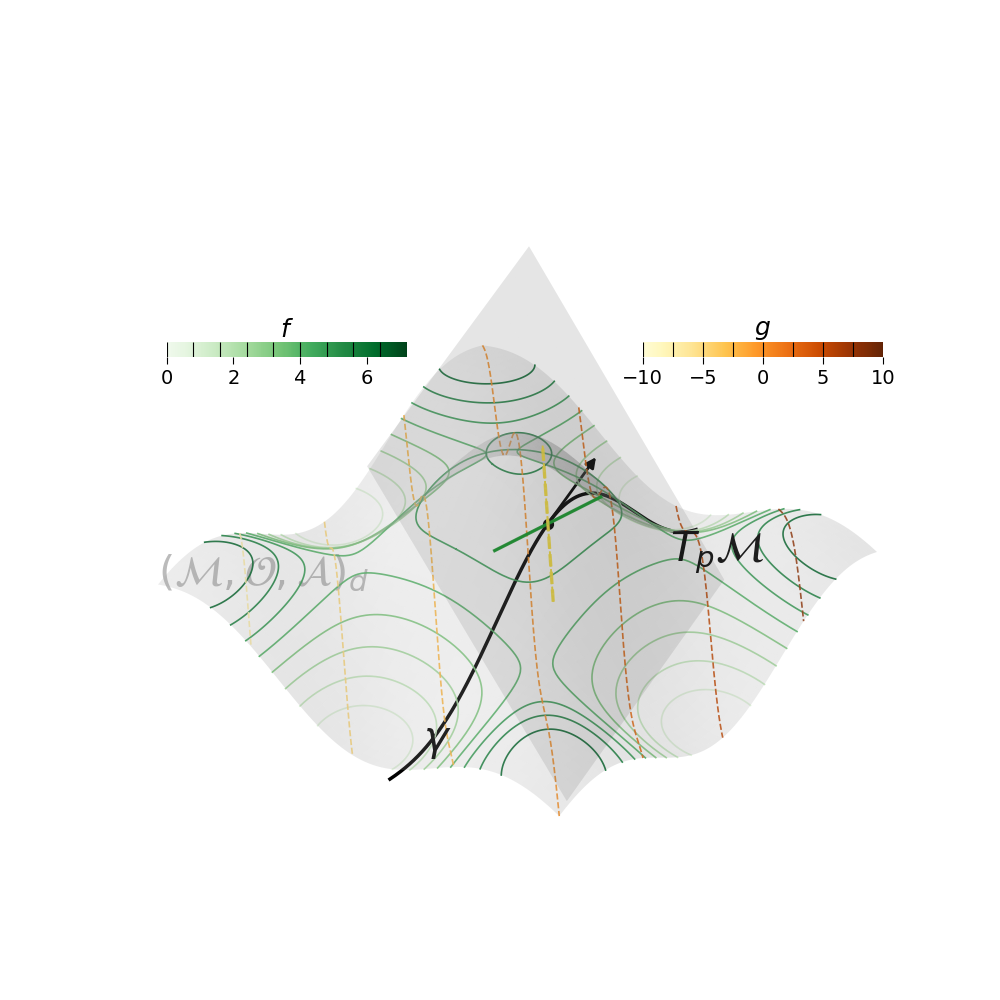

In [6]:
xmin, xmax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi/3
ymin, ymax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi/3

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

plot_manifolds.plot_manifold(
    ax=ax, manifold=manifold, resolution=100, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
    color=colors[-1], alpha=0.2, edgecolor="none", label=r"$\left(\mathcal{M}, \mathcal{O}, \mathcal{A}\right)_d$",
    label_position="left", label_fontsize=30, function=None, cmap="viridis", label_function="Scalar field $f$",
)

plot_covectors.plot_function_level_sets_on_manifold(
    ax=ax, manifold=manifold, function=function_f, levels=9, resolution=250,
    xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax, cmap="Greens", cmap_range=(0.05, 1.0), linestyle="solid", linewidth=1.2, alpha=0.9,
    inset_position=(0.15, 0.65), inset_size=(2.4, 0.15), label_colorbar=r"$f$", label_colorbar_position="top"
)
plot_covectors.plot_function_level_sets_on_manifold(
    ax=ax, manifold=manifold, function=function_g, levels=7, resolution=250,
    xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax, cmap="YlOrBr", cmap_range=(0.05, 1.0), linestyle="dashed", linewidth=1.2, alpha=0.9,
    inset_position=(0.65, 0.65), inset_size=(2.4, 0.15), label_colorbar=r"$g$", label_colorbar_position="top"
)

# plot_charts.plot_chart_region_manifold(
#     ax=ax, surface_manifold=manifold, chart=chart_U,
#     color=colors[0], n_points=2**11, linestyle="dashed", linewidth=1.5,
#     fill_surface=True, alpha=0.15, edgecolor=None, linewidth_fill=0.5,
#     label=r"$\mathcal{U}$", label_position="bottom", label_fontsize=30,
#     draw_endpoints=True, endpoint_color=colors[0], endpoint_size=30,
# )
# plot_charts.plot_chart_region_manifold(
#     ax=ax, surface_manifold=manifold, chart=chart_V,
#     color=colors[1], n_points=2**12, linestyle="dashed", linewidth=1.5,
#     fill_surface=True, alpha=0.15, edgecolor=None, linewidth_fill=0.5,
#     label=r"$\mathcal{V}$", label_position="bottom", label_fontsize=30,
#     draw_endpoints=True, endpoint_color=colors[1], endpoint_size=30,
# )
# plot_charts.plot_chart_region_manifold(
#     ax=ax, surface_manifold=manifold, chart=chart_U_cap_V_X,
#     color=colors[2], n_points=2**12, linestyle="dotted", linewidth=3.5,
#     fill_surface=True, alpha=0.3, edgecolor=None, linewidth_fill=0.5,
#     label=r"$\mathcal{U} \cap \mathcal{V}$", label_position="bottom", label_fontsize=30,
#     draw_endpoints=True, endpoint_color=colors[2], endpoint_size=30,
# )

plot_curves.plot_curve_on_manifold(
    ax=ax, curve=curve_gamma, lambda_range=(-jnp.pi, jnp.pi), n_points=300,
    color="k", linewidth=2.5, label=r"$\gamma$", label_position="start", label_fontsize=30, label_offset=(0.3, 0.3, 0.3)
)
velocity_ambient = curve_gamma.directional_derivative_on_manifold(jnp.array([lambda_0]))
plot_manifolds.plot_tangent_vectors(
    ax=ax, embedded_points=jnp.asarray(p_in_M).reshape(1, 3),
    jacobians=jnp.asarray(velocity_ambient).reshape(1, 1, 3),
    scale=1.0, colors=[["k"]], labels=[[None]], label_fontsize=30,
    mutation_scale=15, linewidth=2.0, draw_points=True, point_color="k", point_size=50
)

param_pts = jnp.array([[p_x, p_y]])
embedded = manifold.embed(param_pts)
jacobians = manifold.derivatives_at_params(param_pts)
plot_manifolds.plot_tangent_spaces(
    ax=ax, embedded_points=embedded, jacobians=jacobians, size=1.6, colors="k",
    alpha=0.1, resolution=10, line_width=2.0, labels=[r"$T_p\mathcal{M}$"], label_fontsize=30,  label_offset=0.6
)

plot_covectors.plot_covector_on_manifold(
    ax=ax, manifold=manifold, chart=chart_U, param_point=p_param, components=X_in_U,
    n_lines=1, level_step=0.0, extent=0.8, color=colors[2], linestyle="solid",
    linewidth=1.2, zero_linewidth=2.4, label=None,
    label_fontsize=30, label_offset=(0., 0., 0.12)
)
plot_covectors.plot_covector_on_manifold(
    ax=ax, manifold=manifold, chart=chart_V, param_point=p_param, components=Y_in_V,
    n_lines=1, level_step=0.0, extent=0.8, color=colors[3], linestyle="dashed",
    linewidth=1.2, zero_linewidth=2.4, label=None,
    label_fontsize=30, label_offset=(0., 0., 0.12)
)

ax.view_init(elev=40.0, azim=-50.0)
ax.set_box_aspect([1, 1, 0.8])
plt.tight_layout()
plt.show()

fig.savefig("../saved_figures_and_videos/"+"Fig_TpstarM_manifold.pdf")

## Chart $(\mathcal{U}, \mathscr{X})$

Thin lines: the true level sets of $f$ and $g$ in chart coordinates. Thick lines: the stacks of
$\mathsf{X}$ and $\mathsf{Y}$, i.e. the linearization at $p$ of those level sets, one line per unit
of covector value. The arrow is the velocity drawn at true scale, so $\mathsf{X}(\mathcal{X})$ and
$\mathsf{Y}(\mathcal{X})$ can be read off as the number of lines it pierces.

In [7]:
import matplotlib.patheffects as path_effects

/home/dlopez/tmp/pip-tmp/ipykernel_506610/3224531199.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


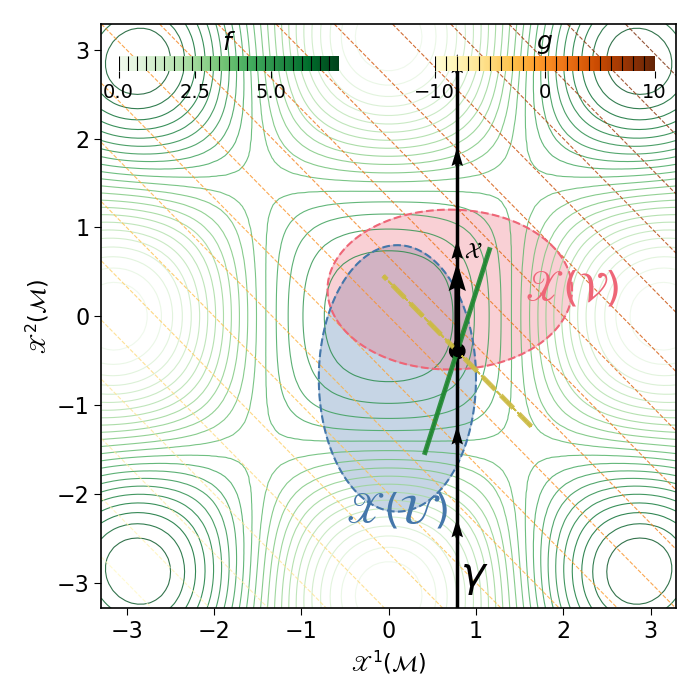

In [8]:
# === Sampling of parameter space, used for the level sets of the scalar fields ===
grid = jnp.linspace(xmin, xmax, 96)
grid_x, grid_y = jnp.meshgrid(grid, grid)
param_points = jnp.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)
simplices = Delaunay(jnp.asarray(param_points)).simplices

# === Window around p, in chart coordinates ===
half_width = 2.0
p_in_chart = jnp.asarray(chart_U.map_to_chart(p_param))

# one level line per unit of covector value: keep only those falling inside the window
n_lines_X = max(1, int(half_width / covector_X.level_spacing_in_chart(chart_U)))
n_lines_Y = max(1, int(half_width / covector_Y.level_spacing_in_chart(chart_U)))

fig, ax = plt.subplots(figsize=(7, 7))

plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=chart_U.boundary_curve, color=colors[0], linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$\mathscr{X}(\mathcal{U})$", label_position="bottom",
    label_fontsize=30, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[0], boundary_marker_size=8
)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=chart_V.boundary_curve, color=colors[1], linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$\mathscr{X}(\mathcal{V})$", label_position="right",
    label_fontsize=30, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[1], boundary_marker_size=8
)
# plot_charts.plot_parametric_region_in_chart_coordinates(
#     ax=ax, chart=chart_U, param_space_data=chart_U_cap_V_X.boundary_curve, color=colors[2], linestyle="dotted",
#     linewidth=3.5, alpha=0.3, label=r"$\mathscr{X}(\mathcal{U} \cap \mathcal{V})$", label_position="center",
#     label_fontsize=30, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
#     mark_boundary_points=False, boundary_marker_color=colors[2], boundary_marker_size=8
# )

# === True level sets of the two scalar fields ===
plot_covectors.plot_function_level_sets_in_chart(
    ax=ax, chart=chart_U, function=function_f, param_space_data=param_points,
    levels=25, simplices=simplices, cmap="Greens", cmap_range=(0.05, 1.0), linestyles="solid",
    linewidths=0.8, alpha=0.8, inset_position=(0.03, 0.92), inset_size=(2.2, 0.15),
    label_colorbar=r"$f$", label_colorbar_position="top"
)
plot_covectors.plot_function_level_sets_in_chart(
    ax=ax, chart=chart_U, function=function_g, param_space_data=param_points,
    levels=21, simplices=simplices, cmap="YlOrBr", cmap_range=(0.05, 1.0), linestyles="dashed",
    linewidths=0.8, alpha=0.8, inset_position=(0.58, 0.92), inset_size=(2.2, 0.15),
    label_colorbar=r"$g$", label_colorbar_position="top"
)

# === Curve gamma ===
p_in_chart = chart_U.map_to_chart(p_param)
ax.scatter(
    p_in_chart[0], p_in_chart[1],
    color="k", s=100, edgecolor="k", label=r"$\mathcal{P} \in \mathcal{U}$",
    path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()]
)
plot_curves.plot_curve_in_chart(
    ax=ax, curve=curve_gamma, chart=chart_U, lambda_range=(-jnp.pi, jnp.pi), n_points=300,
    color="k", linewidth=2.5, label=r"$\gamma$", label_position="start", label_fontsize=30, label_offset=(0.2, 0.6)
)
plot_curves.plot_curve_tangents_in_chart(
    ax=ax, curve=curve_gamma, chart=chart_U, lambda_range=(-jnp.pi, jnp.pi), n_points=500,
    n_arrows=6, color="k", scale=30, width=0.007, label=None, label_fontsize=30, label_offset=(0.05, 0.05)
)
plot_covectors.plot_vector_in_chart(
    ax=ax, base_point=p_in_chart, components=velocity_in_U, scale=1.0, color="black",
    width=0.010, point_size=50, label=r"$\mathcal{X}$", label_fontsize=16,
    label_offset=(0.09*half_width, 0.06*half_width)
)

# === The two covectors, as stacks of level lines ===
plot_covectors.plot_covector_in_chart(
    ax=ax, base_point=p_in_chart, components=X_in_U, n_lines=n_lines_X, level_step=0.0,
    extent=0.60*half_width, color=colors[2], linestyle="solid", linewidth=1.0, zero_linewidth=3.5,
    annotate_levels=False, level_fontsize=9, level_label_shift=0.68*half_width,
    label=None, label_fontsize=30, label_offset=(-0.5*half_width, 0.5*half_width)
)
plot_covectors.plot_covector_in_chart(
    ax=ax, base_point=p_in_chart, components=Y_in_U, n_lines=n_lines_Y, level_step=0.0,
    extent=0.60*half_width, color=colors[3], linestyle="dashed", linewidth=1.0, zero_linewidth=3.5,
    annotate_levels=False, level_fontsize=9, level_label_shift=-0.68*half_width,
    label=None, label_fontsize=30, label_offset=(0.5*half_width, -0.5*half_width)
)

ax.set(
    xlim=(p_in_chart[0] - half_width, p_in_chart[0] + half_width),
    ylim=(p_in_chart[1] - half_width, p_in_chart[1] + half_width),
    xlabel=r"$\mathscr{X}^1$", ylabel=r"$\mathscr{X}^2$",
)
ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), xlabel=r"$\mathscr{X}^1\left( \mathcal{M} \right)$", ylabel=r"$\mathscr{X}^2\left( \mathcal{M} \right)$")
# ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

fig.savefig("../saved_figures_and_videos/"+"Fig_TpstarM_U.pdf")

## Chart $(\mathcal{V}, \mathscr{Y})$

The very same objects seen through the polar chart. Components, orientations and spacings all
change, but the number of lines pierced by the arrow does not. Note as well that the level sets of
$g$, straight lines in the chart $\mathscr{X}$, are curved here: the stack is only the local linear
approximation of the level sets at $p$.

/home/dlopez/tmp/pip-tmp/ipykernel_506610/1738201587.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


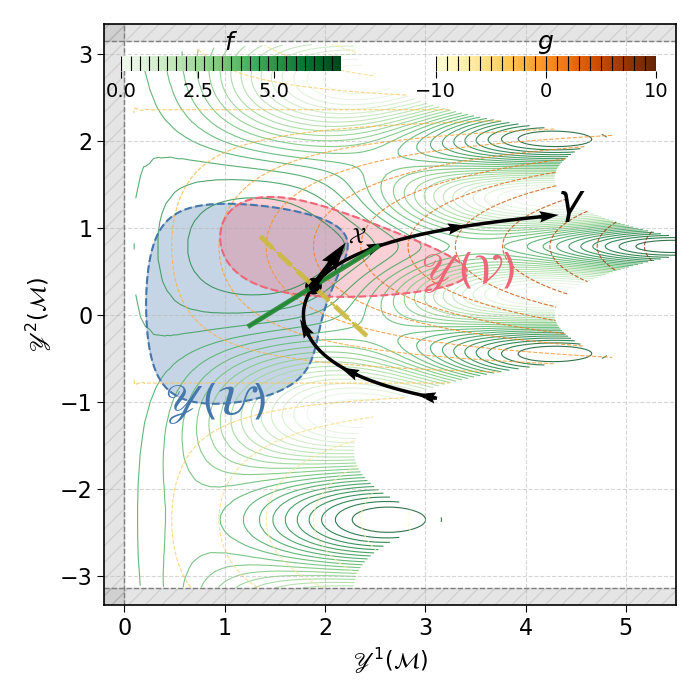

In [9]:
# === Sampling of parameter space, used for the level sets of the scalar fields ===
grid = jnp.linspace(xmin, xmax, 96)
grid_x, grid_y = jnp.meshgrid(grid, grid)
param_points = jnp.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)
simplices = Delaunay(jnp.asarray(param_points)).simplices

# === Window around p, in chart coordinates ===
half_width = 1.3
p_in_chart = jnp.asarray(chart_V.map_to_chart(p_param))

# one level line per unit of covector value: keep only those falling inside the window
n_lines_X = max(1, int(half_width / covector_X.level_spacing_in_chart(chart_V)))
n_lines_Y = max(1, int(half_width / covector_Y.level_spacing_in_chart(chart_V)))

fig, ax = plt.subplots(figsize=(7, 7))

plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=chart_U.boundary_curve, color=colors[0], linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$\mathscr{Y}(\mathcal{U})$", label_position="bottom",
    label_fontsize=30, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[0], boundary_marker_size=8
)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=chart_V.boundary_curve, color=colors[1], linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$\mathscr{Y}(\mathcal{V})$", label_position="right",
    label_fontsize=30, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[1], boundary_marker_size=8
)
# plot_charts.plot_parametric_region_in_chart_coordinates(
#     ax=ax, chart=chart_V, param_space_data=chart_U_cap_V_X.boundary_curve, color=colors[2], linestyle="dotted",
#     linewidth=3.5, alpha=0.3, label=r"$\mathscr{Y}(\mathcal{U} \cap \mathcal{V})$", label_position="center",
#     label_fontsize=30, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
#     mark_boundary_points=False, boundary_marker_color=colors[2], boundary_marker_size=8
# )

# === True level sets of the two scalar fields ===
plot_covectors.plot_function_level_sets_in_chart(
    ax=ax, chart=chart_V, function=function_f, param_space_data=param_points,
    levels=25, simplices=simplices, cmap="Greens", cmap_range=(0.05, 1.0), linestyles="solid",
    linewidths=0.8, alpha=0.8, inset_position=(0.03, 0.92), inset_size=(2.2, 0.15),
    label_colorbar=r"$f$", label_colorbar_position="top"
)
plot_covectors.plot_function_level_sets_in_chart(
    ax=ax, chart=chart_V, function=function_g, param_space_data=param_points,
    levels=21, simplices=simplices, cmap="YlOrBr", cmap_range=(0.05, 1.0), linestyles="dashed",
    linewidths=0.8, alpha=0.8, inset_position=(0.58, 0.92), inset_size=(2.2, 0.15),
    label_colorbar=r"$g$", label_colorbar_position="top"
)

# === Curve gamma ===
p_in_chart = chart_V.map_to_chart(p_param)
ax.scatter(
    p_in_chart[0], p_in_chart[1],
    color="k", s=100, edgecolor="k", label=r"$\mathcal{P} \in \mathcal{U}$",
    path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()]
)
plot_curves.plot_curve_in_chart(
    ax=ax, curve=curve_gamma, chart=chart_V, lambda_range=(-jnp.pi, jnp.pi), n_points=300,
    color="k", linewidth=2.5, label=r"$\gamma$", label_position="end", label_fontsize=30, label_offset=(0.3, 0.15)
)
plot_curves.plot_curve_tangents_in_chart(
    ax=ax, curve=curve_gamma, chart=chart_V, lambda_range=(-jnp.pi, jnp.pi), n_points=500,
    n_arrows=6, color="k", scale=30, width=0.007, label=None, label_fontsize=30, label_offset=(0.05, 0.05)
)
plot_covectors.plot_vector_in_chart(
    ax=ax, base_point=p_in_chart, components=velocity_in_V, scale=1.0, color="black",
    width=0.010, point_size=50, label=r"$\mathcal{X}$", label_fontsize=16,
    label_offset=(0.09*half_width, 0.06*half_width)
)

# === The two covectors, as stacks of level lines ===
plot_covectors.plot_covector_in_chart(
    ax=ax, base_point=p_in_chart, components=X_in_V, n_lines=n_lines_X, level_step=0.0,
    extent=0.60*half_width, color=colors[2], linestyle="solid", linewidth=1.0, zero_linewidth=3.5,
    annotate_levels=False, level_fontsize=9, level_label_shift=0.68*half_width,
    label=None, label_fontsize=30, label_offset=(-0.5*half_width, 0.5*half_width)
)
plot_covectors.plot_covector_in_chart(
    ax=ax, base_point=p_in_chart, components=Y_in_V, n_lines=n_lines_Y, level_step=0.0,
    extent=0.60*half_width, color=colors[3], linestyle="dashed", linewidth=1.0, zero_linewidth=3.5,
    annotate_levels=False, level_fontsize=9, level_label_shift=-0.68*half_width,
    label=None, label_fontsize=16, label_offset=(0.5*half_width, -0.5*half_width)
)

ax.set(xlim=(-0.2, 5.5), ylim=(-jnp.pi-0.2, jnp.pi+0.2),
       xlabel=r"$\mathscr{Y}^1\left( \mathcal{M} \right)$", ylabel=r"$\mathscr{Y}^2\left( \mathcal{M} \right)$")
ax.axvspan(-1, 0, color='grey', alpha=0.2, hatch='//')
ax.axhspan(jnp.pi, jnp.pi+1, color='grey', alpha=0.2, hatch='//')
ax.axhspan(-jnp.pi-1, -jnp.pi, color='grey', alpha=0.2, hatch='//')
ax.axhline(jnp.pi, color='gray', ls='--', lw=1)
ax.axhline(-jnp.pi, color='gray', ls='--', lw=1)
ax.axvline(0, color='gray', ls='--', lw=1)
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

fig.savefig("../saved_figures_and_videos/"+"Fig_TpstarM_V.pdf")